In [1]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# 1. Use a Wikipedia article as your dataset

**a. Select a Wikipedia article of your choice as the corpus for this exercise.**

**b. The article should be reasonably long (at least a few thousand words) for good results.**

In [2]:
WIKI_URL = "https://en.wikipedia.org/wiki/Greek_mythology"
RANDOM_SEED = 42

def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)


def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-GreekMythology-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 2. Preprocess the text coming from the selected corpus.

In [3]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

In [4]:
def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

# 3. Train Skip-gram with Negative Sampling model

**a. Execute the code to train a skipgram.**

**b. Take note of the following properties with Word2Vec, vector size and window.**

`vector_size=100`, `window=5`


In [5]:
def train_sgns(sentences: List[List[str]], window_size: int = 5) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100, # What happens if we change this? Try 50, 200, 300 and see how it affects results.
        window=window_size,
        min_count=1,
        workers=4,
        sg=1,          # 0 = CBOW, 1 = skip-gram
        negative=10,   # negative sampling
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

# 4. Evaluate embeddings using test sets

**a. Evaluate the embedding output using a small test set.**

**b. Change the list of words to be used for evaluation.**

In [6]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }


def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Analogy format: a:b :: c:d
    Checks whether most_similar(positive=[b,c], negative=[a]) returns d.
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }


def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

# 5. Report results

### **Old**

In [10]:

def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    # ===== TRAIN MODEL WITH WINDOW=5 =====
    print("\n" + "="*60)
    print("TRAINING MODEL: Window Size = 5")
    print("="*60)
    
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    print("\nTraining Skip-gram with Negative Sampling (window=5)...")
    model = train_sgns(sentences, window_size=5)
    
    print("Vocabulary size learned:", len(model.wv))

    probe_words = [
        "zeus", "apollo", "athena", "hades", "mythology",
        "olympus", "titan", "god", "hero", "underworld"
    ]
    print_top_neighbors(model, probe_words, topn=8)

    # Domain-specific relatedness test set
    relatedness_test = [

        ("zeus", "thunder", 0.95),
        ("apollo", "god", 0.80),
        ("athena", "wisdom", 0.85),
        ("mythology", "story", 0.90),
        ("olympus", "mountain", 0.90),
        ("hades", "underworld", 0.95),
        ("titan", "mythology", 0.80),
        ("hero", "war", 0.75),
        ("zeus", "pizza", 0.05),
        ("mythology", "tractor", 0.02),
        ("athena", "science", 0.25),
        ("god", "mortal", 0.45),
    ]

    rel_results = evaluate_relatedness(model, relatedness_test)

    print("\n=== Relatedness Test Set (Window=5) ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

    # Small analogy-style test set
    analogy_test = [
        ("zeus", "king", "athena", "wisdom"),
        ("hades", "underworld", "poseidon", "sea"),
        ("mythology", "story", "history", "past"),
        ("hero", "mortal", "god", "immortal"),  # likely OOV or fail, included as test
    ]

    analogy_results = evaluate_analogies(model, analogy_test)

    print("\n=== Analogy Test Set (Window=5) ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    # Example direct similarity checks
    print("\n=== Direct Similarity Checks (Window=5) ===")
    # Change these pairs based on what you expect to be related/unrelated in the article and what words are in the model.
    check_pairs = [
        ("zeus", "olympus"),
        ("zeus", "mythology"),
        ("hades", "underworld"),
        ("zeus", "kitchen"),
    ]
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:10s} <-> {w2:10s}: OOV")

    # Save model
    model.save("exercise_5_skipgram_sgns_window5.model")
    print("\nSaved model to: exercise_5_skipgram_sgns_window5.model")

    print("\nDone.")

main()

Preprocessing text...

=== Corpus Stats ===
num_sentences: 699
num_tokens: 12741
vocab_size: 3937

TRAINING MODEL: Window Size = 5

Training Skip-gram with Negative Sampling (window=5)...
Vocabulary size learned: 3937

=== Nearest Neighbors ===

zeus:
  freed                0.7014
  ayd                  0.6555
  siblings             0.6540
  swallowed            0.6461
  wrapping             0.6443
  caves                0.6400
  ephesus              0.6398
  granddaughter        0.6392

apollo:
  musagetes            0.7474
  thyrxeus             0.7414
  cyaneae              0.7348
  leader               0.7346
  dodona               0.7085
  manifestations       0.6972
  ptoion               0.6927
  graces               0.6854

athena:
  wisdom               0.7804
  courage              0.7756
  pregnant             0.7476
  phallus              0.7471
  owl                  0.7441
  priest               0.7398
  ouroboros            0.7347
  laocoon              0.7342

hades:
  

### **New**

In [11]:

def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    # ===== TRAIN MODEL WITH WINDOW=10 =====
    print("\n" + "="*60)
    print("TRAINING MODEL: Window Size = 10")
    print("="*60)
    
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    print("\nTraining Skip-gram with Negative Sampling (window=10)...")
    model = train_sgns(sentences, window_size=10)
    
    print("Vocabulary size learned:", len(model.wv))

    probe_words = [
        "zeus", "apollo", "athena", "hades", "mythology",
        "olympus", "titan", "god", "hero", "underworld"
    ]
    print_top_neighbors(model, probe_words, topn=8)

    # Domain-specific relatedness test set
    relatedness_test = [

        ("zeus", "thunder", 0.95),
        ("apollo", "god", 0.80),
        ("athena", "wisdom", 0.85),
        ("mythology", "story", 0.90),
        ("olympus", "mountain", 0.90),
        ("hades", "underworld", 0.95),
        ("titan", "mythology", 0.80),
        ("hero", "war", 0.75),
        ("zeus", "pizza", 0.05),
        ("mythology", "tractor", 0.02),
        ("athena", "science", 0.25),
        ("god", "mortal", 0.45),
    ]

    rel_results = evaluate_relatedness(model, relatedness_test)

    print("\n=== Relatedness Test Set (Window=10) ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

    # Small analogy-style test set
    analogy_test = [
        ("zeus", "king", "athena", "wisdom"),
        ("hades", "underworld", "poseidon", "sea"),
        ("mythology", "story", "history", "past"),
        ("hero", "mortal", "god", "immortal"),  # likely OOV or fail, included as test
    ]

    analogy_results = evaluate_analogies(model, analogy_test)

    print("\n=== Analogy Test Set (Window=10) ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    # Example direct similarity checks
    print("\n=== Direct Similarity Checks (Window=10) ===")
    # Change these pairs based on what you expect to be related/unrelated in the article and what words are in the model.
    check_pairs = [
        ("zeus", "olympus"),
        ("zeus", "mythology"),
        ("hades", "underworld"),
        ("zeus", "kitchen"),
    ]
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:10s} <-> {w2:10s}: OOV")

    # Save model
    model.save("exercise_5_skipgram_sgns_window10.model")
    print("\nSaved model to: exercise_5_skipgram_sgns_window10.model")

    print("\nDone.")

main()

Preprocessing text...

=== Corpus Stats ===
num_sentences: 699
num_tokens: 12741
vocab_size: 3937

TRAINING MODEL: Window Size = 10

Training Skip-gram with Negative Sampling (window=10)...
Vocabulary size learned: 3937

=== Nearest Neighbors ===

zeus:
  freed                0.6392
  alcmene              0.6206
  granddaughter        0.6174
  siblings             0.6052
  ayd                  0.5956
  amphiareion          0.5945
  subsequent           0.5940
  plagued              0.5907

apollo:
  leader               0.6805
  cyaneae              0.6595
  musagetes            0.6580
  ptoion               0.6555
  thyrxeus             0.6492
  dodona               0.6410
  manifestations       0.6339
  didyma               0.6295

athena:
  courage              0.7028
  wisdom               0.6957
  phallus              0.6880
  pregnant             0.6853
  burst                0.6834
  laocoon              0.6812
  priest               0.6672
  owl                  0.6645

hades:



PCA VISUALIZATION: Word2Vec

Selected words for visualization: 23/25
Words: ['zeus', 'apollo', 'athena', 'hades', 'poseidon', 'mythology', 'olympus', 'god', 'hero', 'underworld', 'war', 'wisdom', 'sky', 'sea', 'mortal', 'king', 'queen', 'story', 'temple', 'sacrifice', 'prophecy', 'fate', 'epic']

Explained variance ratio: [0.11112822 0.10237158]
Total variance explained: 0.2135

Graph saved as: word2vec_pca_visualization_window10.png


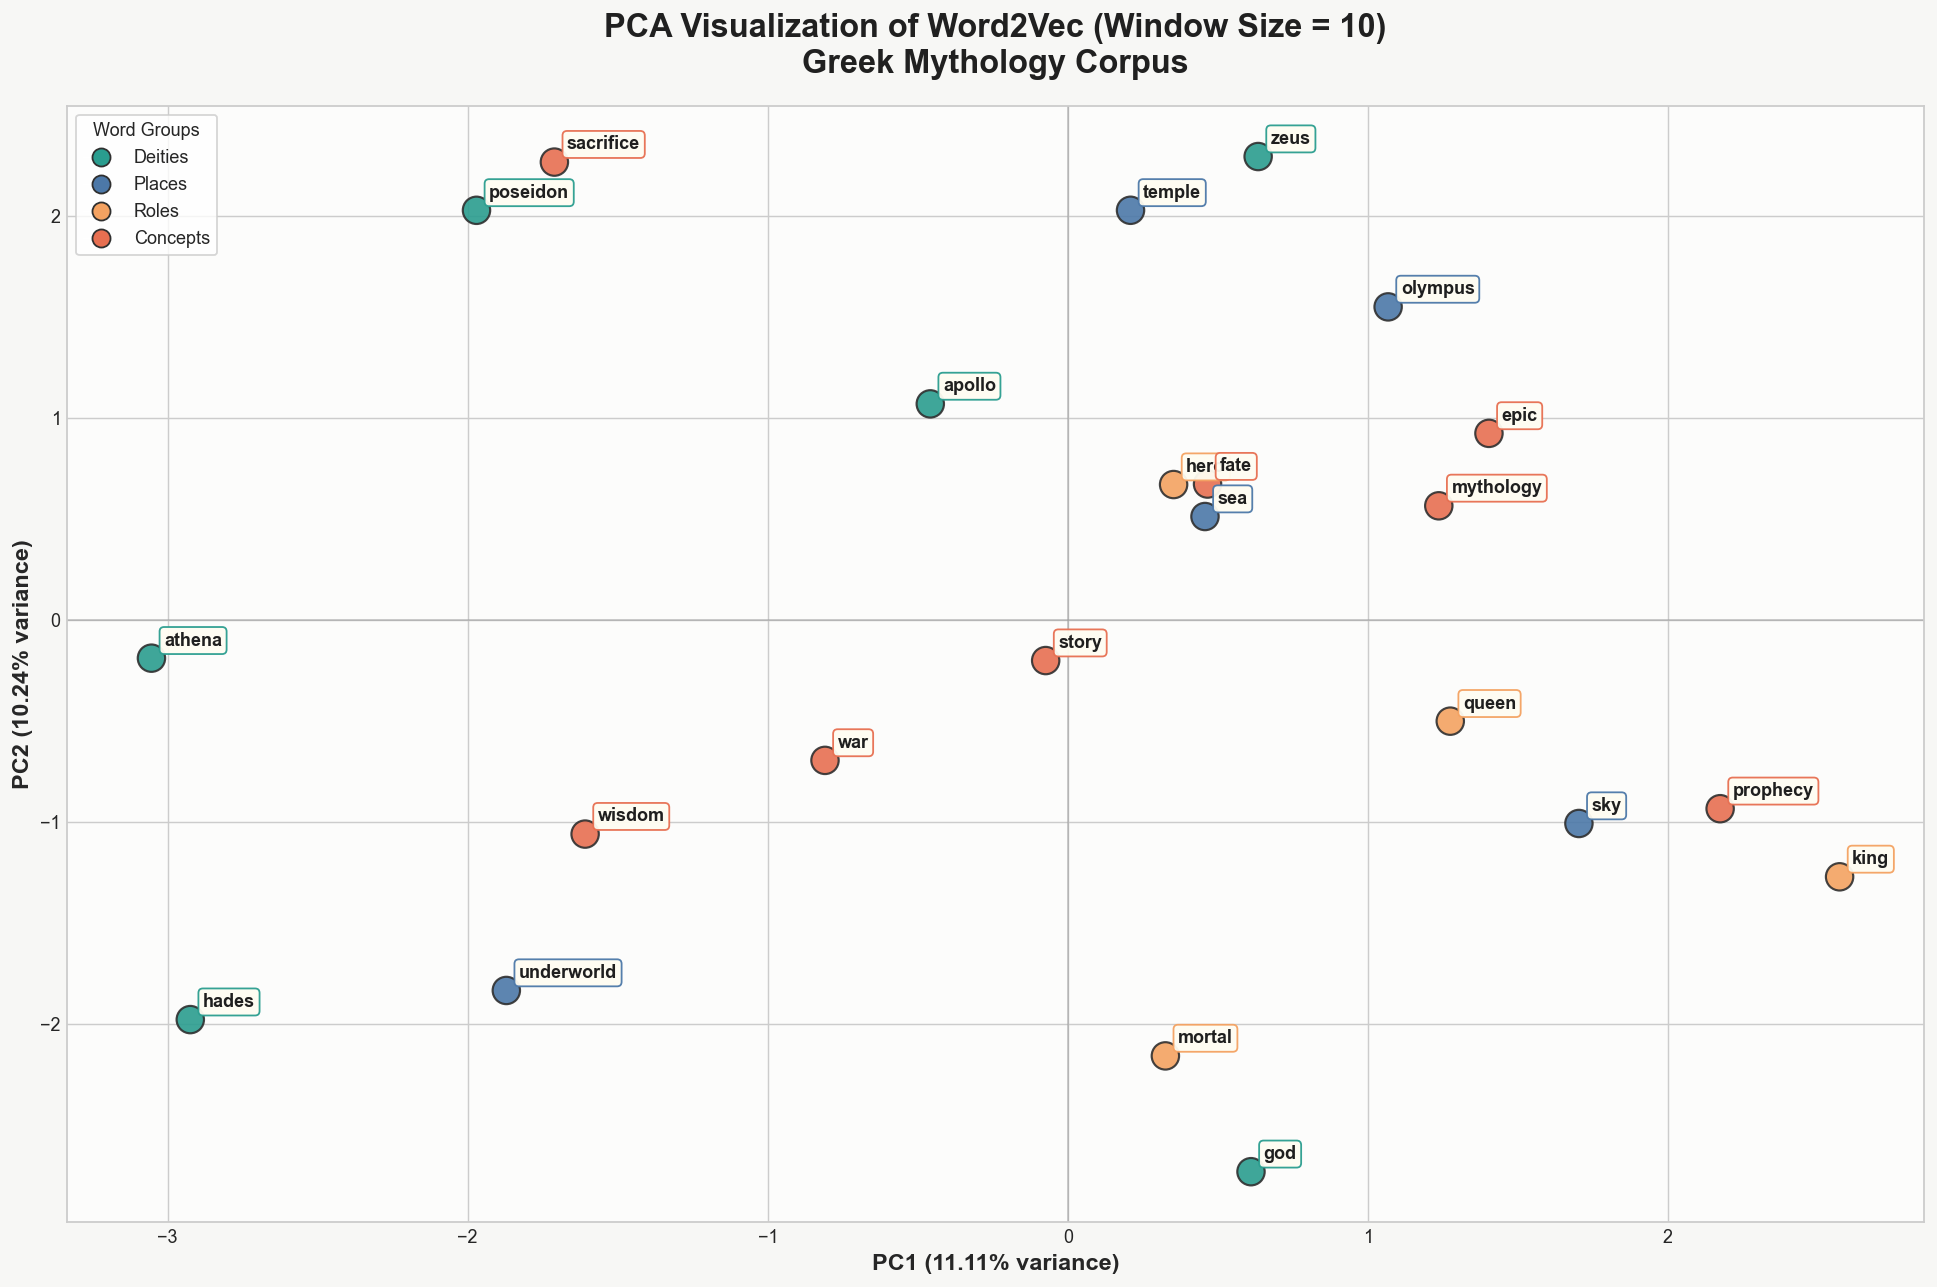

In [12]:
# PCA Visualization (Window=10)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("\n" + "="*80)
print("PCA VISUALIZATION: Word2Vec")
print("="*80)

# Load the trained model
from gensim.models import Word2Vec
model = Word2Vec.load("exercise_5_skipgram_sgns_window10.model")

# Greek mythology words 
selected_words = [
    "zeus", "apollo", "athena", "hades", "poseidon",
    "mythology", "olympus", "titan", "god", "hero",
    "underworld", "war", "wisdom", "sky", "sea",
    "mortal", "immortal", "king", "queen", "story",
    "temple", "sacrifice", "prophecy", "fate", "epic"
]

# Keep only words in vocabulary
words_in_vocab = [word for word in selected_words if word in model.wv.key_to_index]

print(f"\nSelected words for visualization: {len(words_in_vocab)}/{len(selected_words)}")
print(f"Words: {words_in_vocab}\n")

# Build vectors and reduce with PCA
word_vectors = np.array([model.wv[word] for word in words_in_vocab])
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}\n")

# Word groups for color-coding
word_groups = {
    "deities": ["zeus", "apollo", "athena", "hades", "poseidon", "god", "immortal"],
    "places": ["olympus", "underworld", "temple", "sea", "sky"],
    "roles": ["king", "queen", "hero", "mortal", "titan"],
    "concepts": ["mythology", "story", "wisdom", "war", "prophecy", "fate", "epic", "sacrifice"],
}

palette = {
    "deities": "#2A9D8F",
    "places": "#4C78A8",
    "roles": "#F4A261",
    "concepts": "#E76F51",
    "other": "#7A7A7A",
}

# Resolve color for each plotted word
def get_word_group(word):
    for group, items in word_groups.items():
        if word in items:
            return group
    return "other"

colors = [palette[get_word_group(word)] for word in words_in_vocab]

# Plot styling
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 10), dpi=130)
fig.patch.set_facecolor("#F7F7F5")
ax.set_facecolor("#FCFCFB")

# Scatter
ax.scatter(
    word_vectors_2d[:, 0],
    word_vectors_2d[:, 1],
    c=colors,
    s=230,
    alpha=0.9,
    edgecolors="#2F2F2F",
    linewidth=1.2,
)

# Label each point with styled annotation boxes
for i, word in enumerate(words_in_vocab):
    group = get_word_group(word)
    ax.annotate(
        word,
        xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#1F1F1F",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="#FFFDF2",
            ec=palette[group],
            lw=1.0,
            alpha=0.95,
        ),
    )

# Axes and title
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)", fontsize=13, fontweight="bold")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)", fontsize=13, fontweight="bold")
ax.set_title(
    "PCA Visualization of Word2Vec (Window Size = 10)\nGreek Mythology Corpus",
    fontsize=18,
    fontweight="bold",
    pad=18,
    color="#202020",
)

# Add zero lines to improve orientation
ax.axhline(0, color="#999999", linewidth=0.9, alpha=0.55)
ax.axvline(0, color="#999999", linewidth=0.9, alpha=0.55)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Deities", markerfacecolor=palette["deities"], markeredgecolor="#2F2F2F", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="Places", markerfacecolor=palette["places"], markeredgecolor="#2F2F2F", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="Roles", markerfacecolor=palette["roles"], markeredgecolor="#2F2F2F", markersize=10),
    Line2D([0], [0], marker="o", color="w", label="Concepts", markerfacecolor=palette["concepts"], markeredgecolor="#2F2F2F", markersize=10),
]
ax.legend(handles=legend_elements, title="Word Groups", loc="upper left", frameon=True)

plt.tight_layout()

# Save enhanced chart
plt.savefig("word2vec_pca_visualization_window10.png", dpi=180, bbox_inches="tight")
print("Graph saved as: word2vec_pca_visualization_window10.png")

plt.show()